## 线性回归的从零开始实现

In [4]:
#将 Matplotlib 生成的图表直接嵌入到 Notebook 中
%matplotlib inline
import random
import torch
from d2l import torch as d2l

### 构造带有噪声的数据集

In [19]:
def synthetix_data(w, b, num_examples): #生成数据集
    """生成 y=Xw+b+噪声"""
    X = torch.normal(0,1,(num_examples,len(w))) #生成num_examples行、len(w)列的矩阵，矩阵元素服从均值为0、标准差为1的正态分布
    y = torch.matmul(X,w) + b #矩阵乘法
    y += torch.normal(0,0.01,y.shape) #在y上添加均值为0、标准差为0.01的噪声
    return X, y.reshape((-1,1)) #张量默认是行向量，将y变成列向量,-1表示自动计算行数

true_w = torch.tensor([2,-3.4]) #真实权重
true_b = 4.2 #真实偏差
features, labels = synthetix_data(true_w, true_b, 1000) #生成1000个样本

In [20]:
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([0.4609, 1.0696]) 
label: tensor([1.4908])


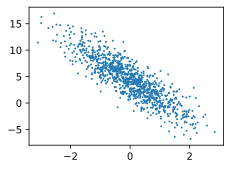

In [21]:
d2l.set_figsize() #设置图的尺寸
d2l.plt.scatter(features[:,1].detach().numpy(), labels.detach().numpy(), 1) #横坐标，纵坐标，点的大小

### 批量读取数据集

定义一个`data_iter`函数，该函数接收批量大小、特征矩阵和标签向量作为输入，生成大小为batch_size的小批量。每个小批量包含一组特征和标签。

* `range(0, 1000, 10)`：意味着 i 会跳着走：0, 10, 20, 30...

* `indices[i : i+batch_size]`：每次抓取 10 个随机的下标。

* `min(...)`：这是为了防止最后一批数据不足 10 个时（比如总数 1005 个）发生越界报错。

* 当执行`yield` 时，函数会把这一小包数据（10 个样本）吐出来。吐完之后，函数没有结束，而是**原地“暂停”**，它记得自己运行到了哪一行，记得 i 是多少。等到外面的 for 循环下一次来要数据时，它会从刚才暂停的地方继续往下跑，直到遇到下一个 yield（也就是下一轮 i 循环）。

In [22]:
def data_iter(batch_size,features,labels):
    num_examples = len(features)
    indices = list(range(num_examples)) #生成一个从0到num_examples-1的列表
    random.shuffle(indices) #将列表元素随机打乱
    for i in range(0,num_examples,batch_size):
        batch_indices = torch.tensor(indices[i: min(i+batch_size,num_examples)]) 
        yield features[batch_indices], labels[batch_indices] 

batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X,'\n',y)
    break
        

tensor([[-0.2261,  0.4568],
        [ 0.4253, -0.5739],
        [-1.8155,  1.0370],
        [ 1.0982,  0.7740],
        [ 1.2540, -0.1572],
        [-1.2154, -0.5925],
        [ 0.9747, -0.4344],
        [ 2.1603, -0.5150],
        [-1.2761, -1.8153],
        [ 0.0280, -0.5043]]) 
 tensor([[ 2.1833],
        [ 7.0127],
        [-2.9591],
        [ 3.7743],
        [ 7.2480],
        [ 3.7823],
        [ 7.6421],
        [10.2831],
        [ 7.8413],
        [ 5.9786]])


### 初始化模型参数
在我们开始用小批量随机梯度下降优化我们的模型参数之前， 我们需要先有一些参数。 在下面的代码中，我们通过从均值为0、标准差为0.01的正态分布中采样随机数来初始化权重， 并将偏置初始化为0。

In [33]:
w = torch.normal(0,0.01,size=(2,1),requires_grad=True) 
b = torch.zeros(1,requires_grad=True) # 1行1列的矩阵，元素全为0

### 定义模型

In [34]:
def linreg(X, w, b):
    return torch.matmul(X,w) + b

### 定义损失函数

In [35]:
def squared_loss(y_hat,y):
    # 均方损失
    return (y_hat - y.reshape(y_hat.shape))**2/2

### 定义优化算法

因为我们计算的损失是一个批量样本的总和，所以我们用批量大小（batch_size） 来规范化步长，这样步长大小就不会取决于我们对批量大小的选择。

In [36]:
def sgd(params,lr,batch_size):
    #小批量随机梯度下降
    with torch.no_grad(): #更新的时候不参与梯度计算
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

### 训练过程

In [37]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l = loss(net(X,w,b),y)
        #因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w,b],lr,batch_size) # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features,w,b),labels)
        print(f'epoch {epoch+1},loss {float(train_l.mean()):f}')

epoch 1,loss 0.027094
epoch 2,loss 0.000099
epoch 3,loss 0.000048


比较真实参数和通过训练学到的参数来评估训练的成功程度

In [38]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([-0.0003,  0.0002], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0009], grad_fn=<RsubBackward1>)


## 线性回归的简洁实现

In [46]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

`TensorDataset` 把特征（features）和标签（labels）一一对应地“装订”在一起

`DataLoader` 喂给它装订好的数据集dataset，每批读取batch_size个。

In [47]:
def load_array(data_arrays,batch_size,is_train=True):
    # 构造一个pytorch数据迭代器
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset,batch_size,shuffle=is_train)

batch_size = 10
data_iter = load_array((features,labels),batch_size)

next(iter(data_iter))

[tensor([[ 0.8801,  0.1137],
         [ 0.0919,  0.0904],
         [ 0.1601,  1.0590],
         [-1.6087,  0.7180],
         [-0.0406,  0.7762],
         [ 0.4499, -0.6755],
         [-0.6553, -0.9573],
         [-0.1972,  1.3744],
         [ 0.6502, -1.2908],
         [ 0.2872, -1.2973]]),
 tensor([[ 5.5505],
         [ 4.0749],
         [ 0.9222],
         [-1.4619],
         [ 1.4790],
         [ 7.4063],
         [ 6.1387],
         [-0.8677],
         [ 9.8927],
         [ 9.1768]])]

In [52]:
from torch import nn
net = nn.Sequential(nn.Linear(2, 1))

# 初始化模型参数
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

loss = nn.MSELoss()
trainer = torch.optim.SGD(net.parameters(),lr=0.03)

In [53]:
num_epochs = 3
for epoch in range(num_epochs):
    for X,y in data_iter:
        l = loss(net(X),y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features),labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000334
epoch 2, loss 0.000098
epoch 3, loss 0.000099


In [54]:
w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：', true_b - b)

w的估计误差： tensor([ 0.0010, -0.0007])
b的估计误差： tensor([-0.0014])
